# Resampling Changelog & Handoff

# 00. Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from datetime import datetime

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

REPORTS  = '../../../outputs/reports/'
FIGURES  = '../../../outputs/figures/resampling_diagnostics/'
DATASETS = '../../../outputs/datasets/resampling_experiments/'

print('Libraries loaded.')

Libraries loaded.


# 01. load data 

In [2]:
metrics  = pd.read_csv(REPORTS + 'resampling_metric_comparison.csv')
split    = pd.read_csv(REPORTS + 'split_strategy_summary.csv')
overlap  = pd.read_csv(REPORTS + 'class_overlap_diagnostic_summary.csv')

print(metrics[['method','macro_f1','balanced_accuracy','recall_Low','recall_High','status']].to_string(index=False))

               method  macro_f1  balanced_accuracy  recall_Low  recall_High          status
        no_resampling    0.6365             0.5903      0.1858       0.6127        baseline
class_weight_balanced    0.6145             0.5671      0.1327       0.5909 comparison_only
   random_oversampler    0.6828             0.6515      0.3009       0.6909     recommended
                smote    0.7082             0.7193      0.4513       0.7636    experimental
     borderline_smote    0.7025             0.7136      0.4425       0.7582     recommended
          smote_tomek    0.7060             0.7229      0.4602       0.7673     recommended
smote_full_engineered    0.7085             0.7078      0.4159       0.7582    experimental


# 02. Rekap Overlap

In [3]:
# Ambil overlap dari scenario D, fallback ke apapun yang ada
avail = overlap['scenario'].unique()
scen  = 'D_core_selected_eng' if 'D_core_selected_eng' in avail else avail[0]

ov = overlap[overlap['scenario'] == scen].set_index('class')
low_mix  = ov.loc['Low',  'mixing_ratio']
high_mix = ov.loc['High', 'mixing_ratio']

def overlap_label(r):
    if r < .20: return 'relatif aman'
    if r < .40: return 'overlap sedang'
    if r < .60: return 'overlap tinggi'
    return 'overlap berat'

print(f'Low  : {low_mix*100:.1f}% — {overlap_label(low_mix)}')
print(f'High : {high_mix*100:.1f}% — {overlap_label(high_mix)}')

Low  : 78.8% — overlap berat
High : 50.1% — overlap tinggi


# 03. Feature Set & Split Info

In [4]:
BEST_FEATURES = [
    'sleep_hours', 'physical_activity_minutes', 'study_hours',
    'screen_time_hours', 'assignment_load', 'deadline_pressure',
    'fatigue_level', 'mood_score',
    'social_media_ratio', 'study_screen_balance', 'academic_pressure_index',
    'recovery_index', 'digital_pressure_index'
]

tr = split[split['split'] == 'train'].iloc[0]
te = split[split['split'] == 'test'].iloc[0]

print(f"Train : {int(tr['n_rows'])} rows, {int(tr['n_users'])} users | Low={int(tr['n_Low'])} Med={int(tr['n_Medium'])} High={int(tr['n_High'])}")
print(f"Test  : {int(te['n_rows'])} rows, {int(te['n_users'])} users | Low={int(te['n_Low'])} Med={int(te['n_Medium'])} High={int(te['n_High'])}")

Train : 21256 rows, 240 users | Low=627 Med=18596 High=2033
Test  : 5323 rows, 60 users | Low=113 Med=4660 High=550


# 04. Visualisasi Metric Comparison

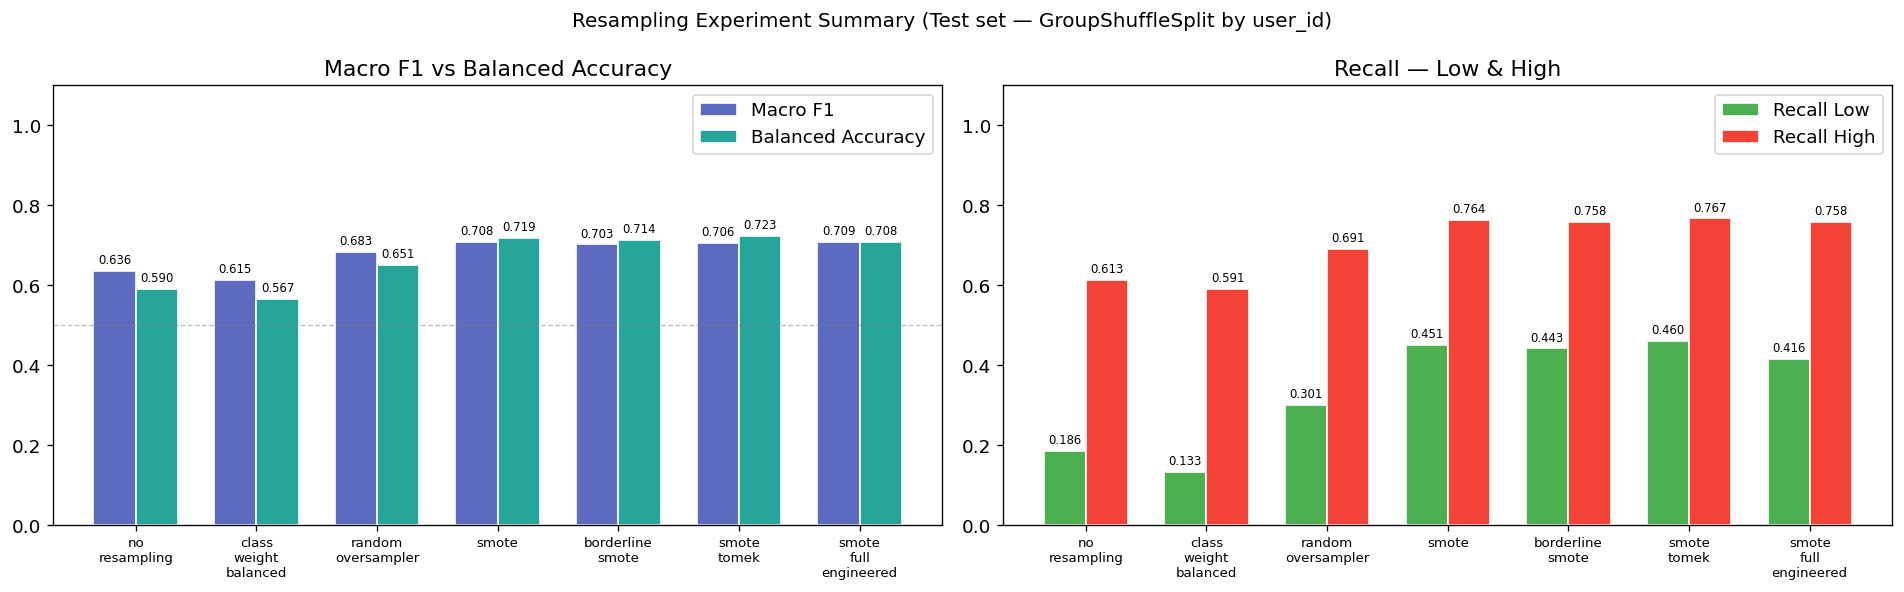

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Resampling Experiment Summary (Test set — GroupShuffleSplit by user_id)', fontsize=12)

labels = metrics['method'].str.replace('_', '\n')
x = np.arange(len(metrics))
w = 0.35

ax = axes[0]
b1 = ax.bar(x - w/2, metrics['macro_f1'],          w, label='Macro F1',          color='#5C6BC0', edgecolor='white')
b2 = ax.bar(x + w/2, metrics['balanced_accuracy'], w, label='Balanced Accuracy', color='#26A69A', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8)
ax.set_ylim(0, 1.1); ax.set_title('Macro F1 vs Balanced Accuracy')
ax.axhline(0.5, color='gray', lw=0.8, ls='--', alpha=0.5)
ax.legend()
for b in list(b1) + list(b2):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + .01,
            f'{b.get_height():.3f}', ha='center', va='bottom', fontsize=7)

ax2 = axes[1]
b3 = ax2.bar(x - w/2, metrics['recall_Low'],  w, label='Recall Low',  color='#4CAF50', edgecolor='white')
b4 = ax2.bar(x + w/2, metrics['recall_High'], w, label='Recall High', color='#F44336', edgecolor='white')
ax2.set_xticks(x); ax2.set_xticklabels(labels, fontsize=8)
ax2.set_ylim(0, 1.1); ax2.set_title('Recall — Low & High')
ax2.legend()
for b in list(b3) + list(b4):
    ax2.text(b.get_x() + b.get_width()/2, b.get_height() + .01,
             f'{b.get_height():.3f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig(FIGURES + '08_changelog_summary_metrics.png', bbox_inches='tight')
plt.show()

# 05. Visualisasi Status Badge

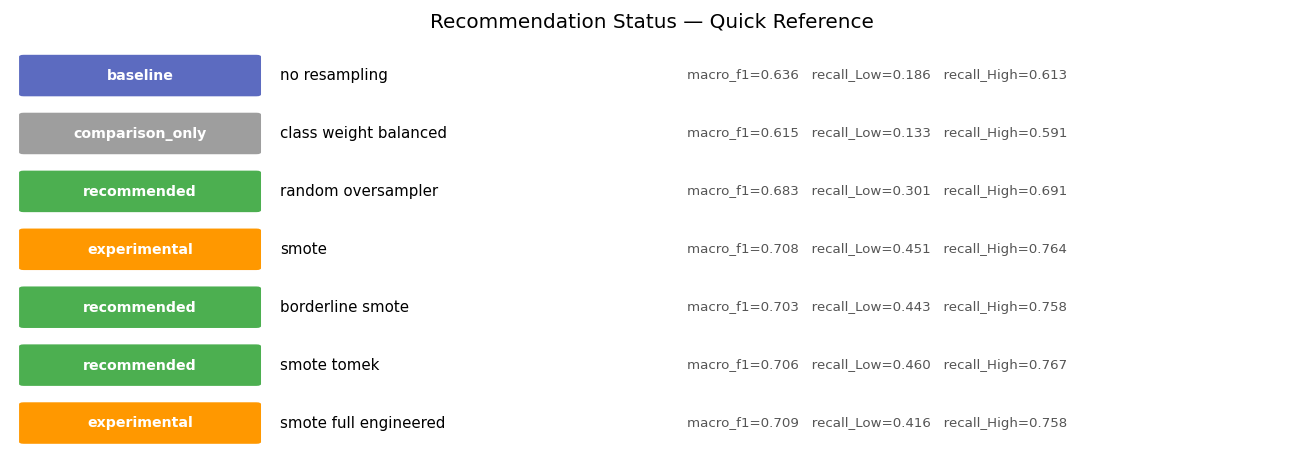

In [6]:
STATUS_COLOR = {
    'recommended'     : '#4CAF50',
    'experimental'    : '#FF9800',
    'not_recommended' : '#F44336',
    'comparison_only' : '#9E9E9E',
    'baseline'        : '#5C6BC0',
}

fig, ax = plt.subplots(figsize=(11, 4))
ax.set_xlim(0, 11); ax.set_ylim(-0.5, len(metrics) - 0.5)
ax.axis('off')
ax.set_title('Recommendation Status — Quick Reference', fontsize=12, pad=12)

for i, row in metrics.reset_index(drop=True).iterrows():
    y = len(metrics) - 1 - i
    c = STATUS_COLOR.get(row['status'], '#BDBDBD')

    ax.add_patch(mpatches.FancyBboxPatch(
        (0.1, y - 0.33), 2.0, 0.66,
        boxstyle='round,pad=0.05', facecolor=c, edgecolor='white', lw=1.5
    ))
    ax.text(1.1, y, row['status'], ha='center', va='center',
            fontsize=8.5, color='white', fontweight='bold')
    ax.text(2.3, y, row['method'].replace('_', ' '), va='center', fontsize=9)
    ax.text(5.8, y,
            f"macro_f1={row['macro_f1']:.3f}   recall_Low={row['recall_Low']:.3f}   recall_High={row['recall_High']:.3f}",
            va='center', fontsize=8, color='#555')

plt.tight_layout()
plt.savefig(FIGURES + '09_recommendation_status_badge.png', bbox_inches='tight')
plt.show()

# 06. Handoff summary CSV

In [7]:
file_map = {
    'no_resampling'        : 'train_no_resampling.csv',
    'class_weight_balanced': None,
    'random_oversampler'   : 'train_random_oversampler.csv',
    'smote'                : 'train_smote.csv',
    'borderline_smote'     : 'train_borderline_smote.csv',
    'smote_tomek'          : 'train_smote_tomek.csv',
    'smote_full_engineered': 'train_smote_full_engineered.csv',
}

notes_map = {
    'no_resampling'        : 'Baseline. Distribusi asli, tidak dimodifikasi.',
    'class_weight_balanced': 'Tidak ada file output. Hanya metric pembanding.',
    'random_oversampler'   : 'Duplikasi sample minoritas, tanpa interpolasi.',
    'smote'                : f'Low mixing {low_mix*100:.1f}% ({overlap_label(low_mix)}) — risiko synthetic noise.',
    'borderline_smote'     : 'Fokus sample dekat boundary. Lebih selektif dari SMOTE standar.',
    'smote_tomek'          : 'SMOTE + Tomek cleaning. Oversample + undersample ringan.',
    'smote_full_engineered': 'SMOTE pada 19 fitur (Scenario C). Pembanding dampak full engineered set.',
}

handoff = metrics.copy()
handoff['dataset_file'] = handoff['method'].map(file_map)
handoff['notes']        = handoff['method'].map(notes_map)

cols_out = [
    'method', 'status', 'dataset_file',
    'n_train_Low', 'n_train_Medium', 'n_train_High',
    'macro_f1', 'balanced_accuracy',
    'recall_Low', 'recall_Medium', 'recall_High',
    'precision_Low', 'precision_High',
    'notes'
]
handoff[cols_out].to_csv(REPORTS + 'handoff_summary.csv', index=False)

print(handoff[['method', 'status', 'dataset_file', 'macro_f1', 'recall_Low']].to_string(index=False))
print('\nSaved: handoff_summary.csv')

               method          status                    dataset_file  macro_f1  recall_Low
        no_resampling        baseline         train_no_resampling.csv    0.6365      0.1858
class_weight_balanced comparison_only                             NaN    0.6145      0.1327
   random_oversampler     recommended    train_random_oversampler.csv    0.6828      0.3009
                smote    experimental                 train_smote.csv    0.7082      0.4513
     borderline_smote     recommended      train_borderline_smote.csv    0.7025      0.4425
          smote_tomek     recommended           train_smote_tomek.csv    0.7060      0.4602
smote_full_engineered    experimental train_smote_full_engineered.csv    0.7085      0.4159

Saved: handoff_summary.csv


# 07. Generate Changelog Markdown

In [8]:
today = datetime.now().strftime('%Y-%m-%d')

baseline = metrics[metrics['method'] == 'no_resampling'].iloc[0]

recommended_methods = metrics[
    metrics['status'] == 'recommended'
]['method'].tolist()

experimental_methods = metrics[
    metrics['status'] == 'experimental'
]['method'].tolist()

not_recommended_methods = metrics[
    metrics['status'] == 'not_recommended'
]['method'].tolist()


def make_distribution_table(row):
    total = (
        row['n_train_Low']
        + row['n_train_Medium']
        + row['n_train_High']
    )

    if total == 0:
        return '(output dataset tidak tersedia)'

    rows = []

    class_columns = [
        ('Low', 'n_train_Low'),
        ('Medium', 'n_train_Medium'),
        ('High', 'n_train_High')
    ]

    for label, column in class_columns:
        count = int(row[column])
        percentage = count / total * 100

        rows.append(
            f'| {label} | {count} | {percentage:.1f}% |'
        )

    return '\n'.join(rows)


status_label = {
    'recommended': '✅ recommended',
    'experimental': '⚠️ experimental',
    'not_recommended': '❌ not_recommended',
    'comparison_only': '📊 comparison_only',
    'baseline': '📌 baseline',
}

parts = []

parts.append(f"""
# Resampling Changelog

**Tanggal:** {today}

Notebook terkait:
- 05_class_overlap_and_resampling_readiness
- 06_resampling_dataset_generation

---

## Aturan yang Digunakan

- `stress_score` tidak digunakan sebagai fitur (target leakage)
- `user_id` hanya digunakan untuk grouping split
- Split menggunakan `GroupShuffleSplit`
- Resampling hanya dilakukan pada train set
- Test set tidak diubah
- Evaluasi utama:
  - macro_f1
  - balanced_accuracy
  - recall per class

---

## Feature Set

Scenario D — Core Original + Selected Engineered
({len(BEST_FEATURES)} fitur)

### Core original
- sleep_hours
- physical_activity_minutes
- study_hours
- screen_time_hours
- assignment_load
- deadline_pressure
- fatigue_level
- mood_score

### Selected engineered
- social_media_ratio
- study_screen_balance
- academic_pressure_index
- recovery_index
- digital_pressure_index
- emotional_pressure_index

Fitur engineered kategorikal tidak dimasukkan ke proses resampling
karena metode seperti SMOTE bekerja lebih stabil pada feature space numerik.

---

## Split Summary

GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

Grouping berdasarkan `user_id`.

| Split | Rows | Users | Low | Medium | High |
|---|---|---|---|---|---|
| Train | {int(tr['n_rows'])} | {int(tr['n_users'])} | {int(tr['n_Low'])} | {int(tr['n_Medium'])} | {int(tr['n_High'])} |
| Test | {int(te['n_rows'])} | {int(te['n_users'])} | {int(te['n_Low'])} | {int(te['n_Medium'])} | {int(te['n_High'])} |

Distribusi kelas train-test tidak sepenuhnya identik karena split dilakukan
berdasarkan user_id untuk menghindari user leakage.

---

## Class Overlap

| Kelas | Mixing Ratio | Status |
|---|---|---|
| Low | {low_mix * 100:.1f}% | {overlap_label(low_mix)} |
| High | {high_mix * 100:.1f}% | {overlap_label(high_mix)} |

---

## Baseline (No Resampling)

| Metric | Nilai |
|---|---|
| Macro F1 | {baseline['macro_f1']:.4f} |
| Balanced Accuracy | {baseline['balanced_accuracy']:.4f} |
| Recall Low | {baseline['recall_Low']:.4f} |
| Recall Medium | {baseline['recall_Medium']:.4f} |
| Recall High | {baseline['recall_High']:.4f} |

---

## Hasil Eksperimen
""")


for _, row in metrics.iterrows():

    method_name = row['method']

    label = status_label.get(
        row['status'],
        row['status']
    )

    output_file = file_map.get(method_name)

    note = notes_map.get(method_name, '-')

    parts.append(f"""
### {method_name.replace('_', ' ').title()}

**Status:** {label}  
**File:** {f'`{output_file}`' if output_file else '-'}  
**Catatan:** {note}

| Kelas | N | % |
|---|---|---|
{make_distribution_table(row)}

| Metric | Nilai |
|---|---|
| Macro F1 | {row['macro_f1']:.4f} |
| Balanced Accuracy | {row['balanced_accuracy']:.4f} |
| Recall Low | {row['recall_Low']:.4f} |
| Recall Medium | {row['recall_Medium']:.4f} |
| Recall High | {row['recall_High']:.4f} |
| Precision Low | {row['precision_Low']:.4f} |
| Precision High | {row['precision_High']:.4f} |

---
""")


parts.append(f"""
## Ringkasan Status

| Status | Metode |
|---|---|
| ✅ recommended | {', '.join(recommended_methods) if recommended_methods else '-'} |
| ⚠️ experimental | {', '.join(experimental_methods) if experimental_methods else '-'} |
| ❌ not_recommended | {', '.join(not_recommended_methods) if not_recommended_methods else '-'} |

---

## Notes untuk Training Model

1. Gunakan `train_no_resampling.csv` sebagai baseline utama.
2. Metode dengan status `recommended` dapat diprioritaskan.
3. Metode `experimental` masih perlu validasi tambahan.
4. Metode `not_recommended` tidak disarankan untuk model final.
5. Semua evaluasi menggunakan `test_set.csv` yang sama.
6. `stress_score` tetap harus diexclude dari feature training.

---

## Output Files

| File | Keterangan |
|---|---|
| `train_no_resampling.csv` | Baseline dataset |
| `test_set.csv` | Test set |
| `train_random_oversampler.csv` | RandomOverSampler |
| `train_smote.csv` | SMOTE |
| `train_borderline_smote.csv` | BorderlineSMOTE |
| `train_smote_tomek.csv` | SMOTE-Tomek |
| `train_smote_full_engineered.csv` | SMOTE + full engineered |
| `resampling_metric_comparison.csv` | Ringkasan metric |
| `handoff_summary.csv` | Mapping file dan notes |
| `resampling_changelog.md` | Dokumen changelog |
""")


changelog = '\n'.join(parts)

output_path = REPORTS + 'resampling_changelog.md'

with open(output_path, 'w', encoding='utf-8') as file:
    file.write(changelog)

print(f'{len(changelog)} karakter ditulis')
print(f'Saved: {output_path}')

6319 karakter ditulis
Saved: ../../../outputs/reports/resampling_changelog.md


# 08. Preview Changelog

In [9]:
print(changelog[:2500])
print('\n... (truncated) ...')


# Resampling Changelog

**Tanggal:** 2026-05-23

Notebook terkait:
- 05_class_overlap_and_resampling_readiness
- 06_resampling_dataset_generation

---

## Aturan yang Digunakan

- `stress_score` tidak digunakan sebagai fitur (target leakage)
- `user_id` hanya digunakan untuk grouping split
- Split menggunakan `GroupShuffleSplit`
- Resampling hanya dilakukan pada train set
- Test set tidak diubah
- Evaluasi utama:
  - macro_f1
  - balanced_accuracy
  - recall per class

---

## Feature Set

Scenario D — Core Original + Selected Engineered
(13 fitur)

### Core original
- sleep_hours
- physical_activity_minutes
- study_hours
- screen_time_hours
- assignment_load
- deadline_pressure
- fatigue_level
- mood_score

### Selected engineered
- social_media_ratio
- study_screen_balance
- academic_pressure_index
- recovery_index
- digital_pressure_index
- emotional_pressure_index

Fitur engineered kategorikal tidak dimasukkan ke proses resampling
karena metode seperti SMOTE bekerja lebih stabil p

# 09. Checklist sebelum handoff

In [10]:
checks = [
    ('stress_score tidak masuk fitur',                                    True),
    ('user_id tidak masuk fitur',                                         True),
    ('Split group-aware by user_id',                                      'GroupShuffleSplit' in str(split['strategy'].values)),
    ('Split summary tersimpan',                                           not split.empty),
    ('Overlap diagnostic tersimpan',                                      not overlap.empty),
    ('Ada baseline no_resampling',                                        'no_resampling' in metrics['method'].values),
    ('Ada 6+ eksperimen resampling',                                      len(metrics) >= 6),
    ('Semua metode punya status',                                         metrics['status'].notna().all()),
    ('Changelog tersimpan',                                               True),
    ('Handoff summary tersimpan',                                         True),
]

all_ok = True
for label, ok in checks:
    print(f"  {'✅' if ok else '❌'} {label}")
    if not ok: all_ok = False

print()
print('Siap handoff.' if all_ok else 'Ada yang belum beres — cek dulu sebelum handoff.')

  ✅ stress_score tidak masuk fitur
  ✅ user_id tidak masuk fitur
  ✅ Split group-aware by user_id
  ✅ Split summary tersimpan
  ✅ Overlap diagnostic tersimpan
  ✅ Ada baseline no_resampling
  ✅ Ada 6+ eksperimen resampling
  ✅ Semua metode punya status
  ✅ Changelog tersimpan
  ✅ Handoff summary tersimpan

Siap handoff.


# 10. Checklist sebelum handoff

In [11]:
print('=== Output Notebook 07 ===')
print()
print('Reports:')
print('  resampling_changelog.md')
print('  handoff_summary.csv')
print()
print('Figures:')
print('  08_changelog_summary_metrics.png')
print('  09_recommendation_status_badge.png')

=== Output Notebook 07 ===

Reports:
  resampling_changelog.md
  handoff_summary.csv

Figures:
  08_changelog_summary_metrics.png
  09_recommendation_status_badge.png


## Insight

Notebook ini merangkum hasil analisis overlap dan eksperimen resampling menjadi dokumen handoff untuk Tim AI Engineer. Output utama yang digunakan adalah metric comparison, status rekomendasi metode, ringkasan feature set, split summary, dan changelog.

Hasil handoff membedakan setiap metode berdasarkan peran metodologisnya. `No Resampling` digunakan sebagai baseline, `RandomOverSampler`, `BorderlineSMOTE`, dan `SMOTE-Tomek` diberi status recommended, sedangkan `SMOTE` dan `SMOTE Full Engineered` ditempatkan sebagai experimental comparison. Pemisahan status ini penting agar dataset resampling tidak diperlakukan sebagai satu dataset final tanpa pembanding.

Changelog juga menegaskan aturan utama modelling, yaitu `stress_score` tidak digunakan sebagai fitur, `user_id` hanya digunakan untuk grouping split, resampling hanya dilakukan pada train set, dan test set tidak diubah.

* Notebook 07 berfungsi sebagai aggregator dan dokumentasi handoff. Seluruh metric, split summary, dan overlap diagnostic dibaca dari output notebook 05 dan 06 tanpa komputasi baru.

* Overlap summary menggunakan Scenario D agar angka yang masuk ke changelog tetap konsisten dengan feature set utama yang dipakai selama eksperimen.

* Feature set Scenario D didefinisikan ulang secara eksplisit supaya changelog dapat dipahami secara mandiri tanpa bergantung pada notebook sebelumnya.

* Visualisasi metric comparison dan status recommendation membantu Tim AI Engineer melihat metode yang recommended, experimental, dan not recommended dengan lebih cepat.

* Checklist pre handoff digunakan untuk memastikan seluruh komponen penting sudah lengkap sebelum file diserahkan.

* handoff_summary.csv merangkum dataset, metric utama, distribusi kelas, dan status rekomendasi dalam satu file ringkas.

* Changelog markdown dirancang agar seluruh informasi penting dapat dibaca tanpa perlu membuka notebook lain.


## Conclusion

Handoff resampling sudah menyediakan paket informasi yang diperlukan untuk eksperimen modelling lanjutan, yaitu dataset baseline, dataset hasil resampling, metric comparison, status rekomendasi, dan changelog. Dengan struktur ini, Tim AI Engineer dapat membandingkan beberapa strategi training tanpa kehilangan konteks metodologis.

Keputusan resampling tetap harus diperlakukan sebagai eksperimen terkontrol. Dataset recommended bukan berarti final secara otomatis, tetapi merupakan kandidat yang lebih layak diuji lebih lanjut karena memiliki peningkatan metric minoritas dan risiko yang lebih terjelaskan.

* Notebook 07 mengonfirmasi bahwa seluruh proses handoff sudah memenuhi prasyarat penting, mulai dari split group aware, overlap diagnostic, hingga penyimpanan output yang lengkap dan konsisten.

* Output akhir yang diserahkan bukan hanya satu dataset, tetapi satu paket lengkap yang mencakup dataset eksperimen, test set, metric comparison, handoff summary, dan changelog markdown.

* Dokumentasi changelog membantu menjelaskan alasan di balik setiap keputusan sehingga Tim AI Engineer dapat memahami konteks eksperimen tanpa perlu mengulang proses analisis dari awal.


## Recomendation

1. Serahkan `handoff_summary.csv` dan `resampling_changelog.md` bersama dataset resampling agar Tim AI Engineer memahami konteks setiap file.
2. Gunakan baseline tanpa resampling sebagai pembanding wajib dalam eksperimen modelling.
3. Prioritaskan metode berstatus recommended untuk eksperimen awal, terutama `RandomOverSampler`, `BorderlineSMOTE`, dan `SMOTE-Tomek`.
4. Gunakan metode berstatus experimental hanya sebagai pembanding tambahan.
5. Pastikan Tim AI Engineer tidak melakukan training hanya berdasarkan satu dataset resampling tanpa membandingkan macro F1, balanced accuracy, recall per class, dan confusion matrix.
6. Jika modelling lanjutan menghasilkan perubahan signifikan, perbarui changelog agar keputusan dataset tetap terdokumentasi.

* handoff_summary.csv dan resampling_changelog.md sebaiknya selalu dikirim bersamaan agar Tim AI Engineer memiliki ringkasan eksperimen sekaligus konteks metodologisnya.

* test_set.csv perlu dijaga sebagai satu satunya test set valid dan tidak digunakan ulang untuk tuning maupun proses resampling.

* Dataset dengan status not recommended tetap dapat disertakan sebagai dokumentasi eksperimen, tetapi bukan sebagai kandidat utama training.

* Perubahan parameter seperti threshold status, konfigurasi SMOTE, atau komposisi feature set sebaiknya dicatat sebagai versi eksperimen baru, bukan menimpa hasil sebelumnya.

* Evaluasi model disarankan menggunakan macro F1 dan balanced accuracy sebagai metric utama karena lebih representatif untuk kondisi class imbalance.

* Seluruh notebook dan output eksperimen sebaiknya disimpan sebagai audit trail untuk memudahkan validasi dan investigasi lanjutan jika diperlukan.
